[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sandeshjung/Machine-Learning-Foundation/blob/main/00_Mathematical_foundation/autograd%28scalar%29.ipynb)

In [1]:
# Colab setup: install the shared helpers (mlf_utils) and any extra packages. Does nothing when run locally.
import sys
if "google.colab" in sys.modules:
    get_ipython().run_line_magic("pip", "install -q git+https://github.com/sandeshjung/Machine-Learning-Foundation.git")

# Autograd (Scalar)

A minimal automatic-differentiation engine that works on single numbers. Every operation produces a `Value` node that remembers:
- `data`: the result of the forward computation
- `_prev`: the child nodes it was computed from
- `_backward`: a closure that applies the **local** chain rule, pushing `out.grad` back to its children
- `grad`: the accumulated derivative of the final output with respect to this node

Theory: [PyTorch Autograd: Automatic Differentiation](README.md#4-automatic-differentiation-autograd)

## Visualising the computation graph
`draw_dot` (from the shared [`mlf_utils`](../mlf_utils/graphs.py) package) walks the graph backwards from the output and renders it with Graphviz. This needs the system `dot` binary, see the main README.

In [2]:
import torch
from mlf_utils import check_close, draw_dot  # draw_dot renders the graph with Graphviz

## The `Value` class
Each operation defines its local derivative:

| Operation | Output | Local derivative |
|---|---|---|
| `a + b` | $a + b$ | $\partial/\partial a = 1,\ \partial/\partial b = 1$ |
| `a * b` | $ab$ | $\partial/\partial a = b,\ \partial/\partial b = a$ |
| `a ** n` | $a^n$ | $n a^{n-1}$ |
| `tanh(a)` | $t = \tanh a$ | $1 - t^2$ |
| `exp(a)` | $e^a$ | $e^a$ |
| `log(a)` | $\ln a$ | $1/a$ |

The chain rule multiplies each local derivative by `out.grad`. Gradients are **accumulated** (`+=`) because a node can feed into several operations.

In [3]:
import math
class Value:
    def __init__(self, value, _children=(), label="", _op=""):
        self.data = value
        self._prev = _children
        self._backward = lambda: None
        self.label=label
        self._op = _op
        self.grad = 0.0
        
    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op="+")

        def _backward():
            self.grad += 1 * out.grad   #dc/da = 1
            other.grad += 1 * out.grad  # dc/db = 1
        out._backward = _backward
        return out
        
    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op="*")

        def _backward():
            self.grad += other.data * out.grad  # dc/da = b
            other.grad += self.data * out.grad  # dc/db = a
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(x) - math.exp(-x))/(math.exp(x) + math.exp(-x))
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self, ), f'e**{self.data}')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def log(self):
        out = Value(math.log(self.data), (self, ), f'log({self.data})')

        def _backward():
            self.grad += 1 / self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self.__mul__(Value(other))
        
    def __repr__(self):
         return str(f'Value: {self.data}')
    def __str__(self):
        return str(f'Value :{self.data}')

## Quick checks of the unary operations

In [4]:
Value(3.0).tanh()

Value: 0.9950547536867306

In [5]:
Value(10.0).exp()

Value: 22026.465794806718

In [6]:
Value(10.0).log()

Value: 2.302585092994046

## Building an expression
$$g = (ab)^2 + (ab)(e + f)$$
broken into intermediate nodes $c = ab$, $d = e + f$, $h = cd$, $c_2 = c^2$ and $g = c_2 + h$.

In [7]:
# g = (a*b)**2 + (a*b)*(e+f)
a = Value(3.0)
a.label = 'a'
b = Value(2.0)
b.label = 'b'
e = Value(5.0, label='e')
f = Value(6.0, label='f')

In [8]:
d = e + f
d.label = 'd'
c = a * b
c.label = 'c'

In [9]:
h = c * d
h.label = 'h'
c2 = c ** 2
c2.label = 'c2'
g = c2 + h
g.label = 'g' 

In [10]:
g

Value: 102.0

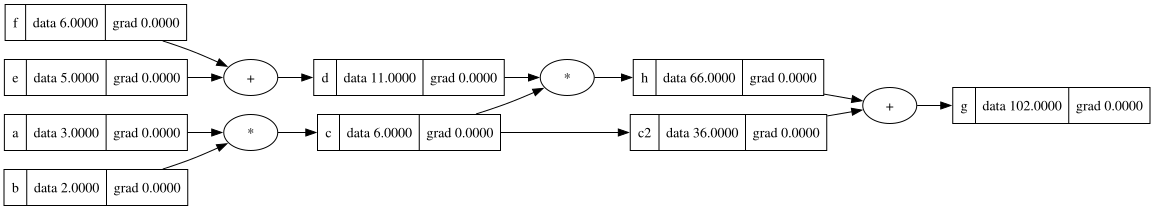

In [11]:
draw_dot(g)

## Backpropagation by hand
Start with $\partial g / \partial g = 1$, then call `_backward()` on each node **from the output towards the inputs** (reverse topological order), so each node's `grad` is complete before it is passed on.

Expected results: $\frac{\partial g}{\partial c} = 2c + d = 23$, so $\frac{\partial g}{\partial a} = 23 \cdot b = 46$ and $\frac{\partial g}{\partial b} = 23 \cdot a = 69$, while $\frac{\partial g}{\partial e} = \frac{\partial g}{\partial f} = c = 6$.

In [12]:
g.grad = 1
g._backward()

In [13]:
h._backward()

In [14]:
c2._backward()
d._backward()
c._backward()

## Verifying with PyTorch
The hand-rolled forward value and gradients should match `torch.autograd` exactly. `check_close` raises an error if they don't, so a broken `_backward` stops the notebook instead of silently giving wrong numbers.

In [15]:
# Check against PyTorch autograd
a_t, b_t, e_t, f_t = (torch.tensor(v, requires_grad=True) for v in (3.0, 2.0, 5.0, 6.0))
g_t = (a_t * b_t) ** 2 + (a_t * b_t) * (e_t + f_t)
g_t.backward()

check_close("g (forward pass)", g.data, g_t)
for name, ours, ref in [("dg/da", a, a_t), ("dg/db", b, b_t), ("dg/de", e, e_t), ("dg/df", f, f_t)]:
    check_close(name, ours.grad, ref.grad)

✓ g (forward pass): matches (max |diff| = 0.00e+00)
✓ dg/da: matches (max |diff| = 0.00e+00)
✓ dg/db: matches (max |diff| = 0.00e+00)
✓ dg/de: matches (max |diff| = 0.00e+00)
✓ dg/df: matches (max |diff| = 0.00e+00)
